# 🧬 AMR-Predictor-ML: Predicting Meropenem Resistance in *Klebsiella pneumoniae*
## Phase 6: Model Interpretability & Serialization (Deployment)

### 📋 Phase Overview
An accurate machine learning model is only valuable in healthcare if it can be trusted. In this final phase, we will unlock the "black box" of our optimized XGBoost model. We will extract the **Top 20 most influential K-mers** that drive the prediction of Meropenem resistance, linking data science back to bacterial biology. Finally, we will export (serialize) the trained model so it can be deployed in a clinical workflow or web application.

### 🎯 Objectives
1. Extract and plot **XGBoost Feature Importance** to identify resistance-associated genomic motifs.
2. Save the final trained model into a standalone binary file (`.pkl`) for production readiness.

⏳ Loading Full Golden Dataset...
🚀 Fitting the Champion XGBoost Model to extract feature importances...


/tmp/ipykernel_2826/4251688002.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_2826/4251688002.py:49: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/azureuser/miniconda3/envs/amr_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


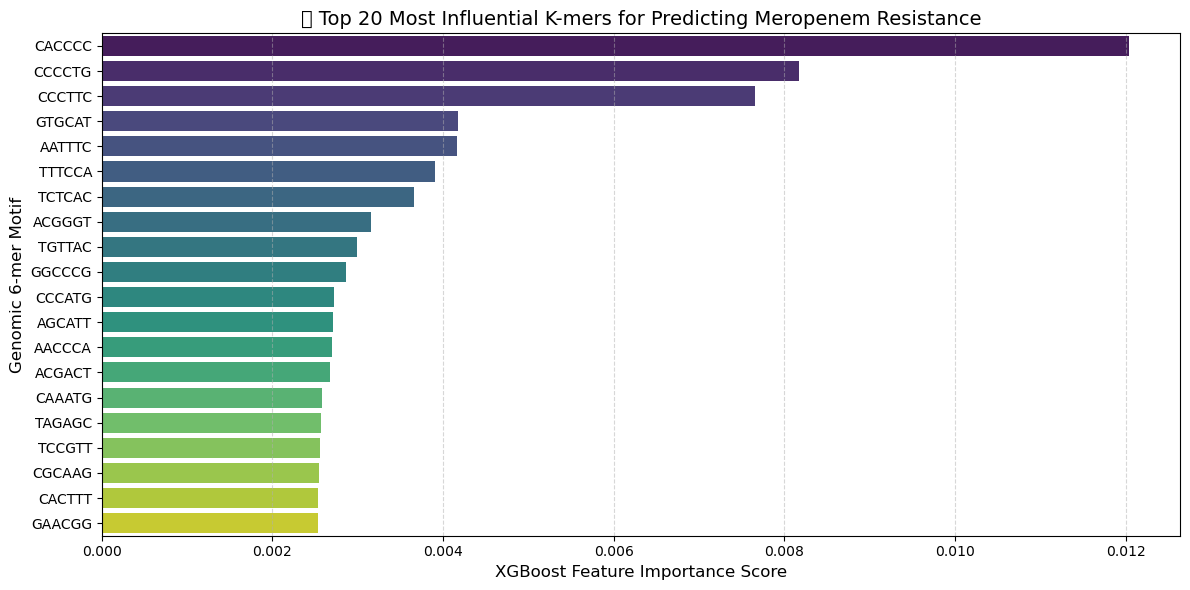


🔝 Top 5 Most Important Genomic Motifs:
K-mer Motif  Importance Score
     CACCCC          0.012034
     CCCCTG          0.008172
     CCCTTC          0.007658
     GTGCAT          0.004180
     AATTTC          0.004157


In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# 1. Load Full Golden Dataset & Re-train the best model to extract weights
dataset_path = "../data/processed/kmers_6_dataset.csv"
print("⏳ Loading Full Golden Dataset...")
df = pd.read_csv(dataset_path)

metadata_cols = ['Genome ID', 'Genome Name', 'Antibiotic', 'Resistant Phenotype', 'AMR_Label']
y = df['AMR_Label'].values
X = df.drop(columns=metadata_cols)
feature_names = X.columns.tolist()

# Train/Test Split (exact same seed)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("🚀 Fitting the Champion XGBoost Model to extract feature importances...")
final_xgb = xgb.XGBClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=6, 
    scale_pos_weight=1.65, random_state=42, n_jobs=-1, eval_metric='logloss'
)
final_xgb.fit(X_train, y_train)

# 2. Extract Feature Importances
importances = final_xgb.feature_importances_
importance_df = pd.DataFrame({
    'K-mer Motif': feature_names,
    'Importance Score': importances
}).sort_values(by='Importance Score', ascending=False).head(20)

# 3. Plot the Top 20 K-mers
plt.figure(figsize=(12, 6))
sns.barplot(
    x='Importance Score', 
    y='K-mer Motif', 
    data=importance_df, 
    palette='viridis'
)
plt.title("🧬 Top 20 Most Influential K-mers for Predicting Meropenem Resistance", fontsize=14)
plt.xlabel("XGBoost Feature Importance Score", fontsize=12)
plt.ylabel("Genomic 6-mer Motif", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\n🔝 Top 5 Most Important Genomic Motifs:")
print(importance_df.head(5).to_string(index=False))

In [2]:
import joblib
import os

# 1. Create a dedicated directory for our trained models (if it doesn't exist)
os.makedirs("../models", exist_ok=True)

# 2. Define the path where the model will be saved
model_path = "../models/final_xgboost_amr_model.pkl"

# 3. Save the model
print("⏳ Saving the Champion XGBoost Model...")
joblib.dump(final_xgb, model_path)

print(f"✅ Success! Model securely saved at: {model_path}")
print("🎉 The model is now officially ready for production deployment (Web API, Clinical Dashboard, etc.).")

⏳ Saving the Champion XGBoost Model...
✅ Success! Model securely saved at: ../models/final_xgboost_amr_model.pkl
🎉 The model is now officially ready for production deployment (Web API, Clinical Dashboard, etc.).
